In [1]:
# ══════════════════════════════════════════════════════════════════════
# Celda 1 — Imports y configuración global  [VERSIÓN ARTÍCULO CIENTÍFICO]
# ══════════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import plotly.graph_objects as go
import plotly.io as pio
import shap
from scipy.stats import theilslopes
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# ─── Estilo para artículo científico ───────────────────────────────
plt.rcParams.update({
    # Resolución — 300 DPI para publicación
    'figure.dpi': 150,
    'savefig.dpi': 300,

    # Tipografía limpia sans-serif
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,

    # ── FONDO BLANCO PURO ──
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.facecolor':'white',

    # Ejes minimalistas
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.linewidth':  0.8,
    'axes.edgecolor':  '#333333',

    # Grid muy sutil — no distrae
    'axes.grid':       True,
    'grid.alpha':      0.25,
    'grid.linewidth':  0.4,
    'grid.color':      '#AAAAAA',
    'grid.linestyle':  '--',

    # Ticks hacia fuera
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'xtick.major.width':  0.8,
    'ytick.major.width':  0.8,
    'xtick.major.size':   3.5,
    'ytick.major.size':   3.5,

    # Leyenda discreta
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#CCCCCC',
    'legend.fancybox':   False,

    # Líneas
    'lines.linewidth': 1.5,
})
pio.renderers.default = 'notebook'

# ─── Paleta accesible para daltónicos (Wong 2011) ──────────────────
C_REAL   = '#D55E00'   # vermillion      — β observado / estimado
C_PRED   = '#0072B2'   # blue            — β predicho
C_CONST  = '#56B4E9'   # sky blue        — β constante
C_STRICT = '#009E73'   # bluish green    — restricciones altas
C_LOOSE  = '#E69F00'   # orange          — restricciones bajas
C_GOLD   = '#CC79A7'   # reddish-purple  — umbral
C_ACCENT = '#0072B2'
C_TEXT   = '#111111'
C_MUTED  = '#555555'

# ─── Parámetros epidemiológicos ────────────────────────────────────
GAMMA = 1 / 7    # tasa de recuperación (período infeccioso 7 días)
SIGMA = 1 / 5    # tasa de progresión E→I (incubación 5 días)
THRESHOLD = 1 / 7  # umbral β = γ → R = 1

# ─── Configuración del experimento ────────────────────────────────
TEST_COUNTRY = 'Spain'
PERIOD       = 'Pre-vaccination'
FEATURES     = [
    'Facial_Coverings_lag14',
    'Restrictions_on_gatherings_lag14',
    'School_closing_lag14',
    'mobility_transit_lag14',
    'Stay_at_home_lag14',
]
FEAT_LABELS = {
    'Facial_Coverings_lag14':           'Uso obligatorio de mascarillas',
    'Restrictions_on_gatherings_lag14': 'Restricciones a reuniones',
    'School_closing_lag14':             'Cierre de centros escolares',
    'mobility_transit_lag14':           'Movilidad en transporte (%)',
    'Stay_at_home_lag14':               'Órdenes de confinamiento domiciliario',
}
WINDOW_DAYS = 14

os.makedirs('figures_sci', exist_ok=True)
print('✅ Configuración artículo científico cargada. País de test:', TEST_COUNTRY)


✅ Configuración artículo científico cargada. País de test: Spain


In [2]:
# ══════════════════════════════════════════════════════════════════════
# Celda 2 — Carga y preparación de datos
# ══════════════════════════════════════════════════════════════════════
# Ajusta la ruta al CSV según donde tengas el archivo
CSV_PATH = 'Europe_countries_covid19.csv'

df_raw = pd.read_csv(CSV_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])

# Filtro pre-vacunación
if PERIOD == 'Pre-vaccination':
    df = df_raw[df_raw['people_fully_vaccinated_per_hundred'] == 0.0].copy()
else:
    df = df_raw.copy()

available_countries = sorted(df['country'].dropna().unique().tolist())
train_countries     = [c for c in available_countries if c != TEST_COUNTRY]

train_df = df[df['country'].isin(train_countries)].copy()
test_df  = df[df['country'] == TEST_COUNTRY].copy()

# Condiciones iniciales SEIR
test_df['I_real'] = test_df['new_cases_smoothed'].rolling(7).sum()
test_df['E_real'] = test_df['new_cases_smoothed'].rolling(5).sum()

# Eliminar NaN en features + beta
required = FEATURES + ['beta']
train_df = train_df.dropna(subset=required).reset_index(drop=True)
test_df  = test_df.dropna(subset=required).reset_index(drop=True)

print(f'✅ Datos cargados: {len(train_df)} filas entrenamiento ({len(train_countries)} países)')
print(f'   Test: {TEST_COUNTRY} — {len(test_df)} filas')
print(f'   Período test: {test_df["date"].min().date()} → {test_df["date"].max().date()}')
print(f'   Países entrenamiento: {train_countries}')

✅ Datos cargados: 2445 filas entrenamiento (8 países)
   Test: Spain — 321 filas
   Período test: 2020-03-03 → 2021-01-17
   Países entrenamiento: ['Austria', 'Belgium', 'France', 'Germany', 'Italy', 'Poland', 'Portugal', 'United Kingdom']


In [3]:
# ══════════════════════════════════════════════════════════════════════
# Celda 3 — Estimación de β(t) mediante Theil-Sen (ventana móvil)
#
# Método:
#   1. Se asume S(t) ≈ N (período pre-vacunación)
#   2. La linealización del SEIR da la ecuación característica:
#      (r + γ)(r + σ) = βσ  →  β(t) = (r(t)+γ)(r(t)+σ) / σ
#   3. r(t) se estima como la pendiente de log(new_cases) en W=14 días
#      usando el estimador robusto de Theil-Sen (punto de ruptura 29.3%)
# ══════════════════════════════════════════════════════════════════════

def estimate_beta_theilsen(series_cases, window=14, gamma=GAMMA, sigma=SIGMA):
    """Estima β(t) usando Theil-Sen sobre ventanas móviles de log(casos)."""
    n = len(series_cases)
    beta_arr = np.full(n, np.nan)
    log_cases = np.where(series_cases > 0, np.log(series_cases), np.nan)
    t_arr = np.arange(n, dtype=float)

    for i in range(window - 1, n):
        start = i - window + 1
        t_win = t_arr[start:i+1]
        y_win = log_cases[start:i+1]
        mask  = ~np.isnan(y_win)
        if mask.sum() < 4:
            continue
        try:
            result = theilslopes(y_win[mask], t_win[mask])
            r = float(result[0])
            beta_arr[i] = (r + gamma) * (r + sigma) / sigma
        except Exception:
            pass

    return beta_arr


# Verificamos que el dataset ya contiene la columna 'beta' (calculada en el pipeline de la app)
# Si no, la recalculamos aquí
if 'beta' not in test_df.columns or test_df['beta'].isna().all():
    print('Recalculando β(t) con Theil-Sen...')
    test_df['beta'] = estimate_beta_theilsen(test_df['new_cases_smoothed'].values)
    test_df = test_df.dropna(subset=['beta']).reset_index(drop=True)

print(f'✅ β(t) disponible. Rango: [{test_df["beta"].min():.4f}, {test_df["beta"].max():.4f}]')
print(f'   Media: {test_df["beta"].mean():.4f} | Mediana: {test_df["beta"].median():.4f}')
print(f'   Días con β > γ (R>1): {(test_df["beta"] > GAMMA).sum()} de {len(test_df)}')

✅ β(t) disponible. Rango: [0.0432, 1.6126]
   Media: 0.2239 | Mediana: 0.1429
   Días con β > γ (R>1): 155 de 321


In [4]:
# ══════════════════════════════════════════════════════════════════════
# Celda 4 — Entrenamiento del modelo Extra Trees (zero-shot)
# ══════════════════════════════════════════════════════════════════════

# Preparar datos de entrenamiento y test
X_train = train_df[FEATURES]
y_train = train_df['beta']
X_test  = test_df[FEATURES]
y_test  = test_df['beta']

# Extra Trees — modelo seleccionado en el TFM
model = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=9,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
test_df['beta_pred'] = y_pred

# Métricas
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rho  = float(np.corrcoef(y_test, y_pred)[0, 1])

print('✅ Modelo Extra Trees entrenado (zero-shot sobre España)')
print(f'   R²     = {r2:.4f}')
print(f'   MSE    = {mse:.5f}')
print(f'   MAE    = {mae:.5f}')
print(f'   Pearson ρ = {rho:.4f}')

# Valores SHAP
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print('✅ Valores SHAP calculados.')

✅ Modelo Extra Trees entrenado (zero-shot sobre España)
   R²     = 0.8401
   MSE    = 0.01028
   MAE    = 0.06901
   Pearson ρ = 0.9223
✅ Valores SHAP calculados.


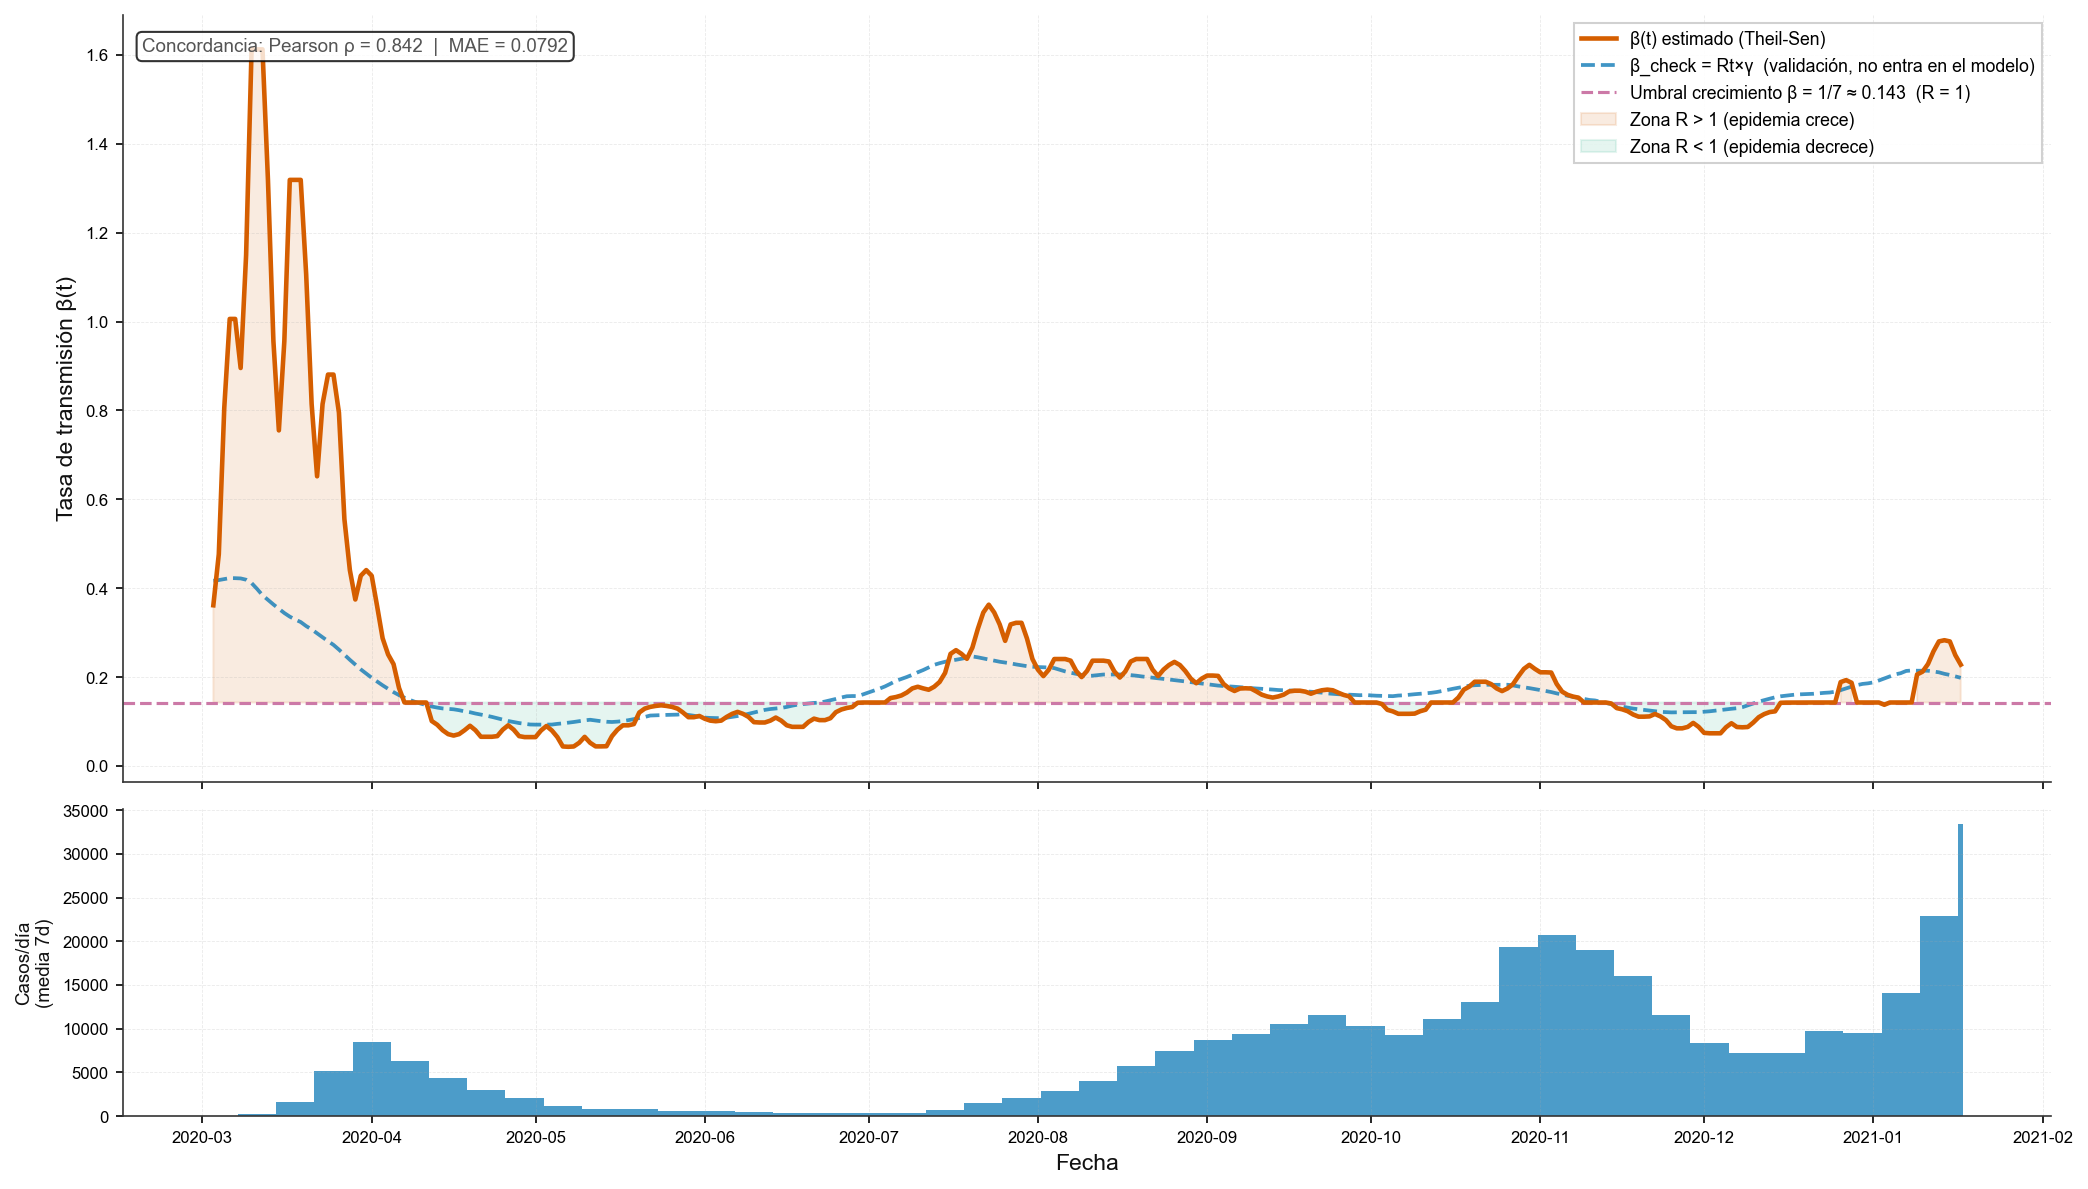

✅ Figura 1 guardada en figures/fig01_beta_estimado_validacion.png


In [5]:
# ----------------------------------------------------------------------
# β(t) estimado por Theil-Sen + validación externa β_check = Rt×γ
# -----------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [3, 1.2]},
                                sharex=True)
# fig.suptitle(f'β(t) Estimado (Theil-Sen) · {TEST_COUNTRY} · Validación externa Rt×γ',
#              fontsize=14, fontweight='bold', color=C_TEXT, y=0.98)

# ── Panel superior: β(t) ──
ax1.plot(test_df['date'], test_df['beta'],
         color=C_REAL, linewidth=2.2, label='β(t) estimado (Theil-Sen)', zorder=3)

if 'reproduction_rate' in test_df.columns and test_df['reproduction_rate'].notna().any():
    beta_check = test_df['reproduction_rate'] * GAMMA
    ax1.plot(test_df['date'], beta_check,
             color=C_PRED, linewidth=1.8, linestyle='--', alpha=0.75,
             label='β_check = Rt×γ  (validación, no entra en el modelo)')
    # Métricas de concordancia
    common = pd.DataFrame({'est': test_df['beta'], 'chk': beta_check}).dropna()
    rho_v  = np.corrcoef(common['est'], common['chk'])[0, 1]
    mae_v  = np.abs(common['est'] - common['chk']).mean()
    ax1.text(0.01, 0.97,
             f'Concordancia: Pearson ρ = {rho_v:.3f}  |  MAE = {mae_v:.4f}',
             transform=ax1.transAxes, fontsize=9, va='top', color=C_MUTED,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax1.axhline(THRESHOLD, color=C_GOLD, linewidth=1.5, linestyle='--',
            label=f'Umbral crecimiento β = 1/7 ≈ {THRESHOLD:.3f}  (R = 1)')
ax1.fill_between(test_df['date'], test_df['beta'], THRESHOLD,
                 where=(test_df['beta'] > THRESHOLD),
                 alpha=0.12, color=C_REAL, label='Zona R > 1 (epidemia crece)')
ax1.fill_between(test_df['date'], test_df['beta'], THRESHOLD,
                 where=(test_df['beta'] <= THRESHOLD),
                 alpha=0.10, color=C_STRICT, label='Zona R < 1 (epidemia decrece)')

ax1.set_ylabel('Tasa de transmisión β(t)', fontsize=11, color=C_TEXT)
ax1.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax1.set_title('', fontsize=1)

# ── Panel inferior: nuevos casos suavizados ──
if 'new_cases_smoothed' in test_df.columns:
    ax2.bar(test_df['date'], test_df['new_cases_smoothed'],
            color=C_ACCENT, alpha=0.7, width=1)
    ax2.set_ylabel('Casos/día\n(media 7d)', fontsize=9, color=C_TEXT)

ax2.set_xlabel('Fecha', fontsize=11, color=C_TEXT)

plt.tight_layout()
plt.savefig('figures_sci/fig01_beta_estimado_validacion.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 1 guardada en figures/fig01_beta_estimado_validacion.png')

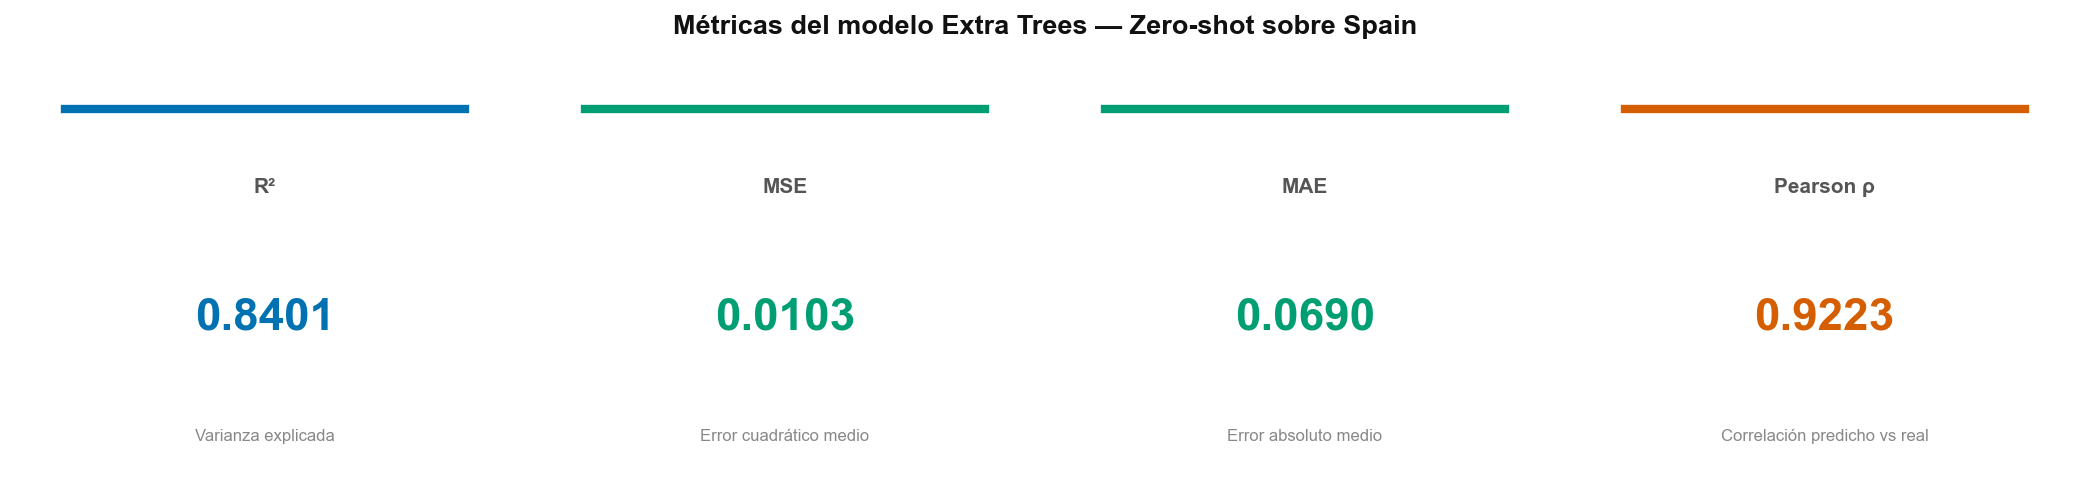

✅ Figura 2 guardada en figures/fig02_metricas_modelo.png


In [6]:
# ══════════════════════════════════════════════════════════════════════
# Celda 6 — FIGURA 2
# Tarjetas de métricas del modelo Extra Trees
# ══════════════════════════════════════════════════════════════════════

metrics = {'R²': (r2, 'Varianza explicada'),
           'MSE':      (mse, 'Error cuadrático medio'),
           'MAE':      (mae, 'Error absoluto medio'),
           'Pearson ρ':(rho, 'Correlación predicho vs real')}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
fig.suptitle(f'Métricas del modelo Extra Trees — Zero-shot sobre {TEST_COUNTRY}',
             fontsize=13, fontweight='bold', color=C_TEXT, y=1.02)

colors = [C_PRED, C_STRICT, C_STRICT, C_REAL]
for ax, (name, (val, sub)), col in zip(axes, metrics.items(), colors):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.75, name, ha='center', va='center',
            transform=ax.transAxes, fontsize=10,
            fontweight='600', color=C_MUTED)
    ax.text(0.5, 0.42, f'{val:.4f}', ha='center', va='center',
            transform=ax.transAxes, fontsize=22,
            fontweight='bold', color=col)
    ax.text(0.5, 0.12, sub, ha='center', va='center',
            transform=ax.transAxes, fontsize=8, color='#888888')
    ax.axhline(0.95, color=col, linewidth=4, xmin=0.1, xmax=0.9)

plt.tight_layout()
plt.savefig('figures_sci/fig02_metricas_modelo.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 2 guardada en figures/fig02_metricas_modelo.png')

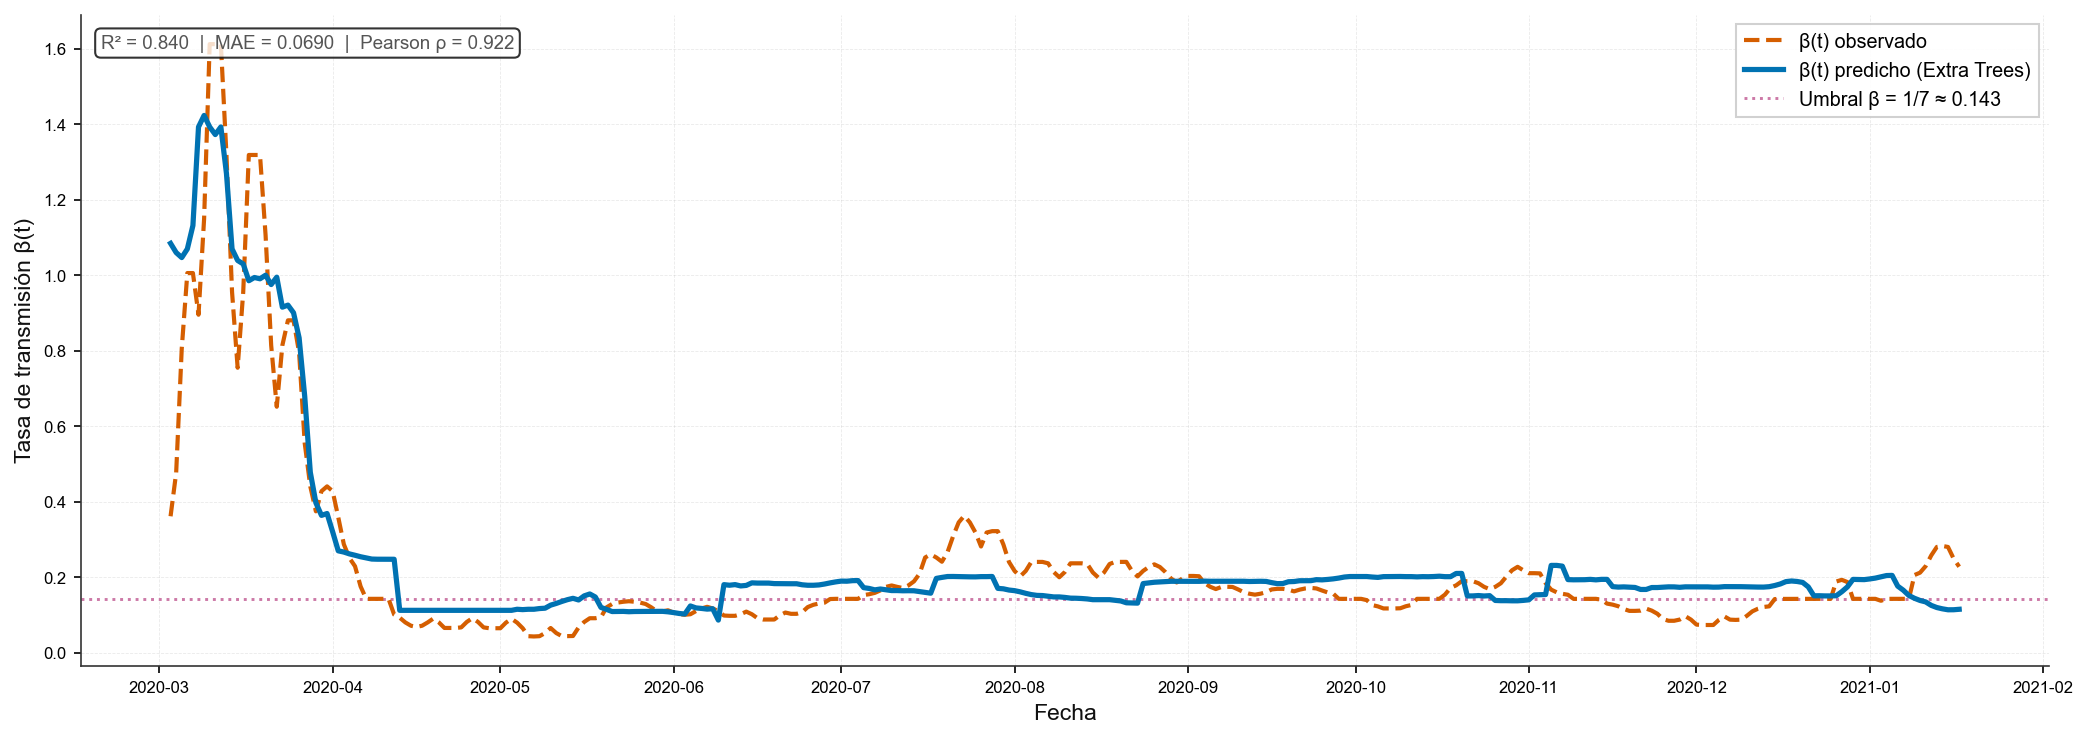

✅ Figura 3 guardada en figures/fig03_beta_observado_predicho.png


In [7]:
# ══════════════════════════════════════════════════════════════════════
# Celda 7 — FIGURA 3
# Serie temporal β observado vs β predicho por Extra Trees
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df['date'], y_test,
        color=C_REAL, linewidth=2, linestyle='--', label='β(t) observado', zorder=3)
ax.plot(test_df['date'], y_pred,
        color=C_PRED, linewidth=2.5, label='β(t) predicho (Extra Trees)', zorder=4)
ax.axhline(THRESHOLD, color=C_GOLD, linewidth=1.4, linestyle=':',
           label=f'Umbral β = 1/7 ≈ {THRESHOLD:.3f}')

# ax.set_title(f'β observado vs predicho · {TEST_COUNTRY}', fontsize=13,
#              fontweight='bold', color=C_TEXT, pad=10)
ax.set_xlabel('Fecha', fontsize=11, color=C_TEXT)
ax.set_ylabel('Tasa de transmisión β(t)', fontsize=11, color=C_TEXT)
ax.legend(fontsize=9.5, framealpha=0.9)
ax.text(0.01, 0.97,
        f'R² = {r2:.3f}  |  MAE = {mae:.4f}  |  Pearson ρ = {rho:.3f}',
        transform=ax.transAxes, fontsize=9, va='top', color=C_MUTED,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures_sci/fig03_beta_observado_predicho.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 3 guardada en figures/fig03_beta_observado_predicho.png')

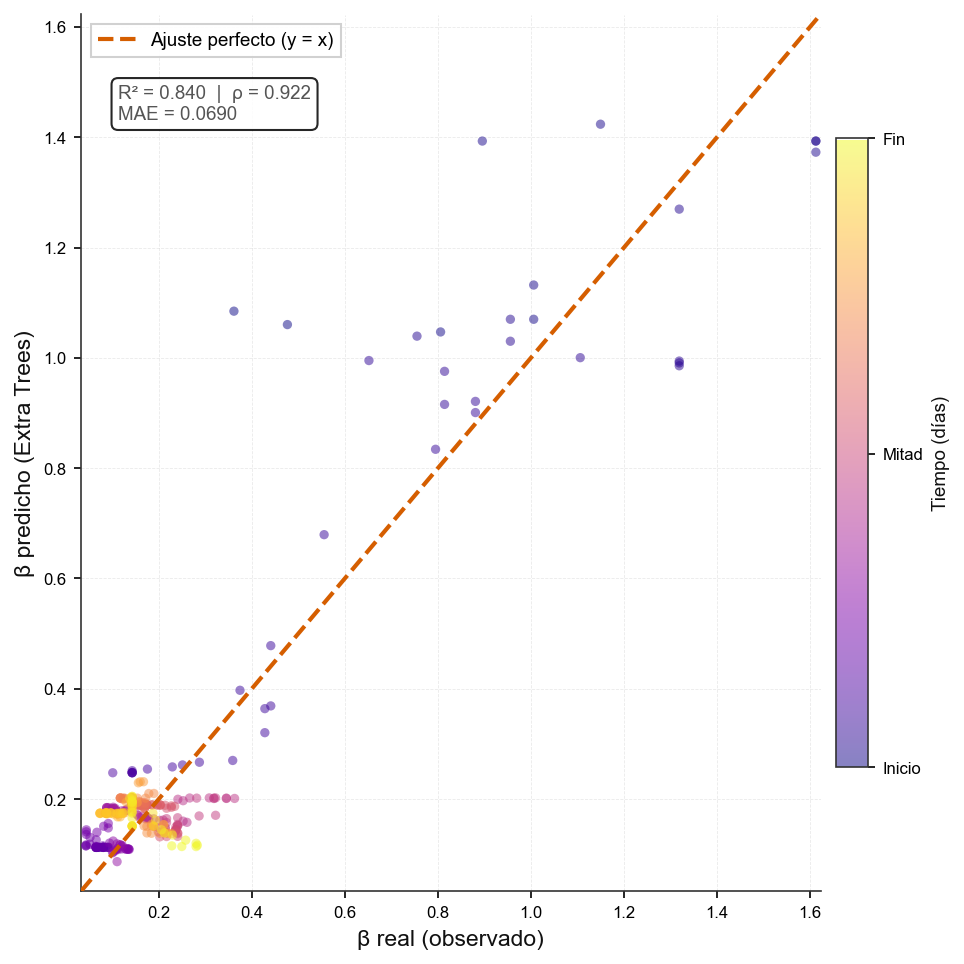

✅ Figura 4 guardada en figures/fig04_scatter_beta.png


In [8]:
# ══════════════════════════════════════════════════════════════════════
# Celda 8 — FIGURA 4
# Scatter plot β real vs β predicho
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# Gradiente temporal
n = len(y_test)
colors_scatter = plt.cm.plasma(np.linspace(0.1, 0.9, n))
sc = ax.scatter(y_test, y_pred, c=np.arange(n), cmap='plasma',
                s=20, alpha=0.5, linewidths=0, zorder=3)

lim = [min(float(y_test.min()), float(y_pred.min())) - 0.01,
       max(float(y_test.max()), float(y_pred.max())) + 0.01]
ax.plot(lim, lim, color=C_REAL, linewidth=2, linestyle='--',
        label='Ajuste perfecto (y = x)', zorder=4)
ax.set_xlim(lim); ax.set_ylim(lim)

# ax.set_title(f'β real vs predicho · {TEST_COUNTRY}',
#              fontsize=12, fontweight='bold', color=C_TEXT)
ax.set_xlabel('β real (observado)', fontsize=11, color=C_TEXT)
ax.set_ylabel('β predicho (Extra Trees)', fontsize=11, color=C_TEXT)
ax.legend(fontsize=9)

cbar = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('Tiempo (días)', fontsize=9, color=C_TEXT)
cbar.set_ticks([0, n//2, n])
cbar.set_ticklabels(['Inicio', 'Mitad', 'Fin'])

ax.text(0.05, 0.92,
        f'R² = {r2:.3f}  |  ρ = {rho:.3f}\nMAE = {mae:.4f}',
        transform=ax.transAxes, fontsize=9, va='top', color=C_MUTED,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig('figures_sci/fig04_scatter_beta.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 4 guardada en figures/fig04_scatter_beta.png')

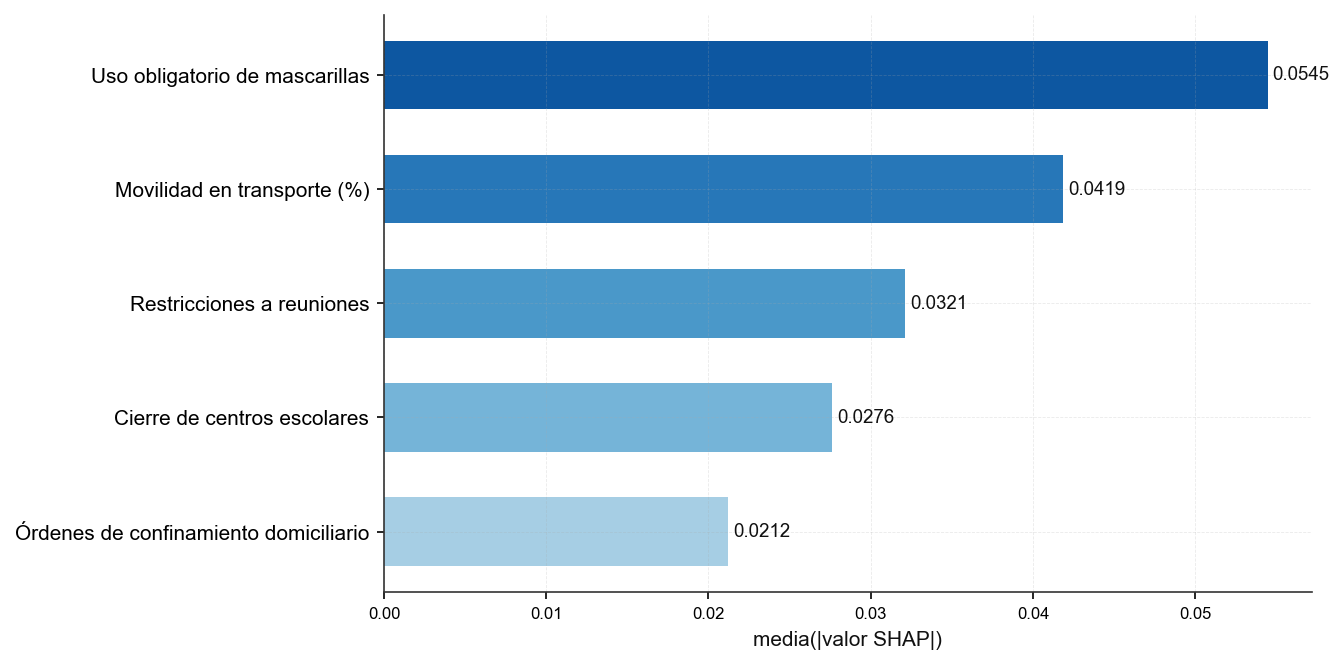

✅ Figura 5 guardada en figures/fig05_shap_global_barplot.png


In [9]:
# ══════════════════════════════════════════════════════════════════════
# Celda 9 — FIGURA 5
# SHAP global — bar plot de importancia media |SHAP|
# ══════════════════════════════════════════════════════════════════════

mean_shap = np.abs(shap_values).mean(axis=0)
imp_df    = pd.DataFrame({
    'Feature': [FEAT_LABELS[f] for f in FEATURES],
    'SHAP':    mean_shap
}).sort_values('SHAP', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(imp_df['Feature'], imp_df['SHAP'],
               color=plt.cm.Blues(np.linspace(0.35, 0.85, len(imp_df))),
               edgecolor='none', height=0.6)

for bar, val in zip(bars, imp_df['SHAP']):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color=C_TEXT)

# ax.set_title(f'Importancia global de variables (media |SHAP|) · {TEST_COUNTRY}',
#              fontsize=12, fontweight='bold', color=C_TEXT, pad=12)
ax.set_xlabel('media(|valor SHAP|)', fontsize=10, color=C_TEXT)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('figures_sci/fig05_shap_global_barplot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 5 guardada en figures/fig05_shap_global_barplot.png')

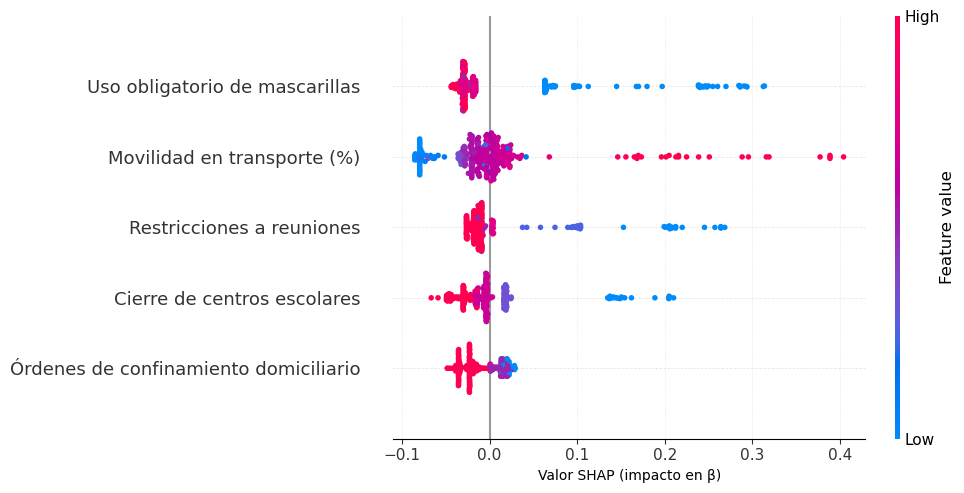

✅ Figura 6 guardada en figures/fig06_shap_beeswarm.png


In [10]:
# ══════════════════════════════════════════════════════════════════════
# Celda 10 — FIGURA 6
# SHAP global — beeswarm plot
# ══════════════════════════════════════════════════════════════════════

plt.style.use('default')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.25,'grid.linewidth':0.4,'grid.color':'#AAAAAA','grid.linestyle':'--','font.family':'sans-serif','font.size':9,'axes.titlesize':10,'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,'legend.framealpha':0.9,'legend.edgecolor':'#CCCCCC','legend.fancybox':False,'lines.linewidth':1.5,'xtick.direction':'out','ytick.direction':'out'})
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=[FEAT_LABELS[f] for f in FEATURES],
    show=False,
    plot_size=None,
    color_bar=True,
    max_display=len(FEATURES),
)
# plt.title(f'SHAP Beeswarm — Impacto de cada NPI sobre β(t) · {TEST_COUNTRY}',
#           fontsize=12, fontweight='bold', color=C_TEXT, pad=12)
plt.xlabel('Valor SHAP (impacto en β)', fontsize=10)
plt.tight_layout()
plt.savefig('figures_sci/fig06_shap_beeswarm.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('✅ Figura 6 guardada en figures/fig06_shap_beeswarm.png')

Fecha seleccionada para waterfall: 2020-03-10  (β = 1.6126)


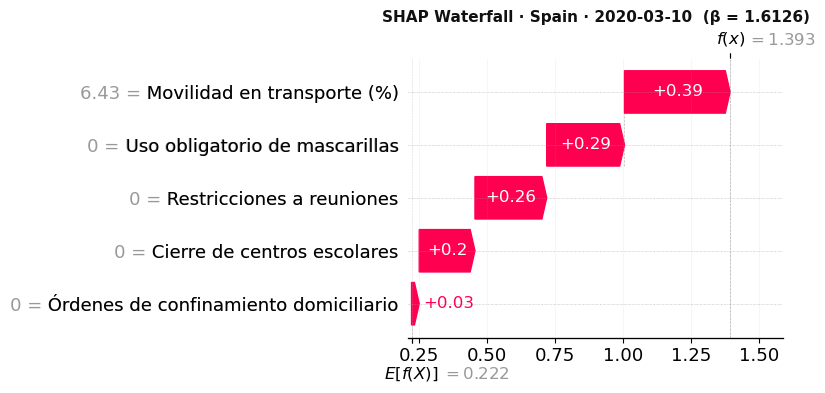

✅ Figura 7 guardada en figures/fig07_shap_waterfall_local.png


In [11]:
# ══════════════════════════════════════════════════════════════════════
# Celda 11 — FIGURA 7
# SHAP local — waterfall para la observación con β más alto
# (equivale a seleccionar una fecha de máxima transmisión en el dashboard)
# ══════════════════════════════════════════════════════════════════════

# Índice de la observación con mayor β real
idx_max_beta = int(y_test.values.argmax())
date_max     = test_df['date'].iloc[idx_max_beta].date()
beta_max_val = float(y_test.iloc[idx_max_beta])

print(f'Fecha seleccionada para waterfall: {date_max}  (β = {beta_max_val:.4f})')

plt.style.use('default')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.25,'grid.linewidth':0.4,'grid.color':'#AAAAAA','grid.linestyle':'--','font.family':'sans-serif','font.size':9,'axes.titlesize':10,'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,'legend.framealpha':0.9,'legend.edgecolor':'#CCCCCC','legend.fancybox':False,'lines.linewidth':1.5,'xtick.direction':'out','ytick.direction':'out'})
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx_max_beta],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx_max_beta],
        feature_names=[FEAT_LABELS[f] for f in FEATURES],
    ),
    show=False,
)
plt.title(f'SHAP Waterfall · {TEST_COUNTRY} · {date_max}  (β = {beta_max_val:.4f})',
          fontsize=11, fontweight='bold', color=C_TEXT)
plt.tight_layout()
plt.savefig('figures_sci/fig07_shap_waterfall_local.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 7 guardada en figures/fig07_shap_waterfall_local.png')

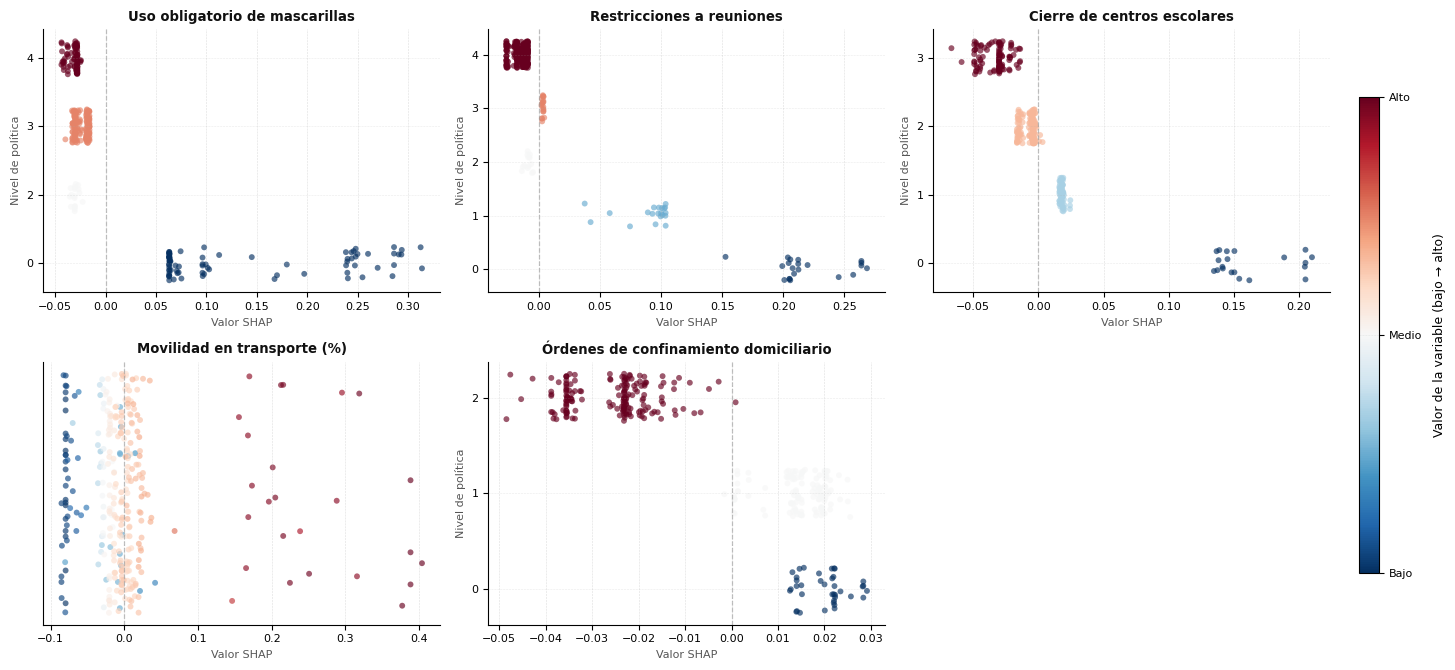

✅ Figura 8 guardada en figures/fig08_shap_distribucion_por_nivel.png


In [12]:
# ══════════════════════════════════════════════════════════════════════
# Celda 12 — FIGURA 8
# Distribución SHAP por nivel de política para cada variable
# ══════════════════════════════════════════════════════════════════════

CONTINUOUS_FEATS = {'mobility_transit_lag14', 'stringency_index_lag14'}

n_feats      = len(FEATURES)
cols_per_row = min(n_feats, 3)
n_rows       = (n_feats + cols_per_row - 1) // cols_per_row

plt.style.use('default')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.25,'grid.linewidth':0.4,'grid.color':'#AAAAAA','grid.linestyle':'--','font.family':'sans-serif','font.size':9,'axes.titlesize':10,'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,'legend.framealpha':0.9,'legend.edgecolor':'#CCCCCC','legend.fancybox':False,'lines.linewidth':1.5,'xtick.direction':'out','ytick.direction':'out'})
fig, axes = plt.subplots(n_rows, cols_per_row,
                          figsize=(cols_per_row * 4.5, n_rows * 3.4),
                          squeeze=False)
fig.patch.set_facecolor('white')
# fig.suptitle(f'Distribución SHAP por nivel de política · {TEST_COUNTRY}',
#              fontsize=13, fontweight='bold', color=C_TEXT, y=1.01)

cmap = plt.cm.RdBu_r
rng  = np.random.default_rng(42)

for idx, feat in enumerate(FEATURES):
    ri, ci  = divmod(idx, cols_per_row)
    ax      = axes[ri][ci]
    ax.set_facecolor('white')

    feat_vals = X_test[feat].values.astype(float)
    shap_col  = shap_values[:, idx]
    vmin, vmax = feat_vals.min(), feat_vals.max()
    norm_vals  = (feat_vals - vmin) / (vmax - vmin + 1e-9)

    if feat not in CONTINUOUS_FEATS:
        levels     = sorted(np.unique(feat_vals.astype(int)))
        y_pos_map  = {lv: i for i, lv in enumerate(levels)}
        for lv in levels:
            mask   = feat_vals.astype(int) == lv
            sv     = shap_col[mask]
            nv     = norm_vals[mask]
            y_jit  = y_pos_map[lv] + rng.uniform(-0.25, 0.25, sv.shape)
            ax.scatter(sv, y_jit, c=nv, cmap=cmap, vmin=0, vmax=1,
                       s=18, alpha=0.65, linewidths=0)
        ax.set_yticks(list(y_pos_map.values()))
        ax.set_yticklabels([str(lv) for lv in levels], fontsize=8)
        ax.set_ylabel('Nivel de política', fontsize=8, color=C_MUTED)
    else:
        sort_i = np.argsort(feat_vals)
        y_jit  = rng.uniform(-0.4, 0.4, feat_vals.shape)
        ax.scatter(shap_col[sort_i], y_jit[sort_i],
                   c=norm_vals[sort_i], cmap=cmap, vmin=0, vmax=1,
                   s=18, alpha=0.65, linewidths=0)
        ax.set_yticks([])

    ax.axvline(0, color='#999', linewidth=0.9, linestyle='--', alpha=0.6)
    ax.set_title(FEAT_LABELS[feat], fontsize=9.5, fontweight='600', color=C_TEXT)
    ax.set_xlabel('Valor SHAP', fontsize=8, color=C_MUTED)
    ax.grid(axis='x', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for idx in range(n_feats, n_rows * cols_per_row):
    ri, ci = divmod(idx, cols_per_row)
    axes[ri][ci].set_visible(False)

sm  = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar_ax = fig.add_axes([1.01, 0.15, 0.015, 0.7])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('Valor de la variable (bajo → alto)', fontsize=9, labelpad=8)
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(['Bajo', 'Medio', 'Alto'])

fig.tight_layout(pad=1.2)
plt.savefig('figures_sci/fig08_shap_distribucion_por_nivel.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 8 guardada en figures/fig08_shap_distribucion_por_nivel.png')

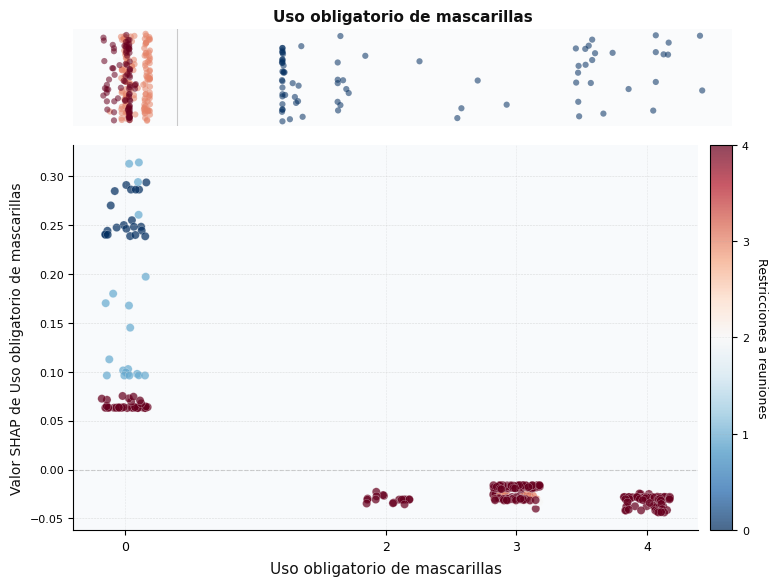

✅ Figura 09 guardada en figures_sci/fig09_dependence_Facial_Coverings_lag.png


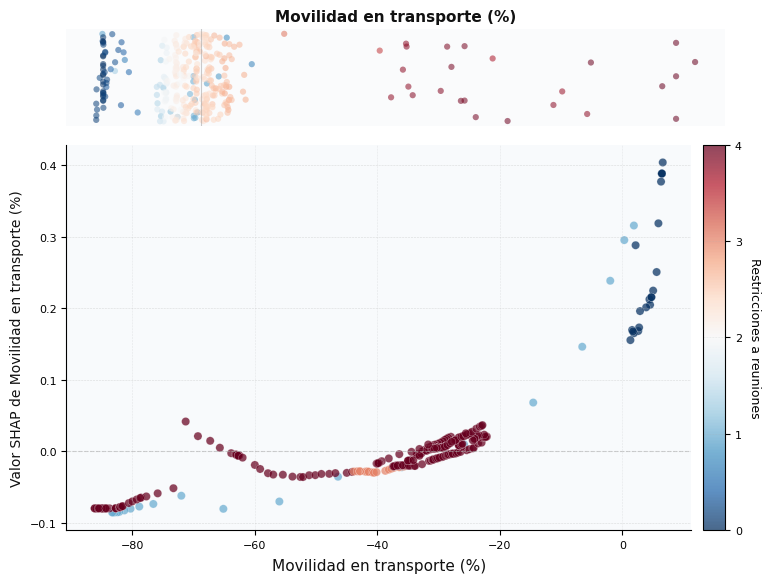

✅ Figura 10 guardada en figures_sci/fig10_dependence_mobility_transit_lag.png


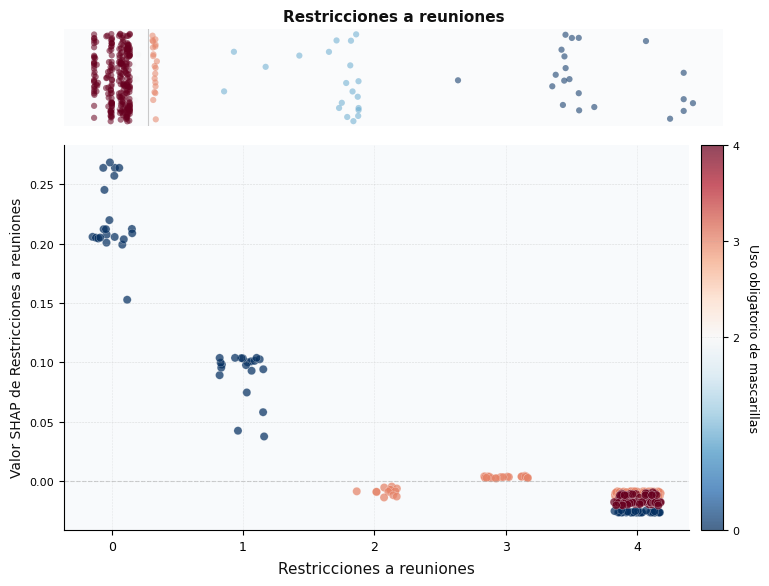

✅ Figura 11 guardada en figures_sci/fig11_dependence_Restrictions_on_gath.png


In [13]:
# ══════════════════════════════════════════════════════════════════════
# Celda 13 — FIGURAS 9, 10, 11
# Dependence plots: mascarillas, movilidad en tránsito, restricciones reuniones
# ══════════════════════════════════════════════════════════════════════

DEP_TARGETS = [
    ('Facial_Coverings_lag14',           'Restrictions_on_gatherings_lag14', '09'),
    ('mobility_transit_lag14',           'Restrictions_on_gatherings_lag14', '10'),
    ('Restrictions_on_gatherings_lag14', 'Facial_Coverings_lag14',           '11'),
]

cmap_dep = shap.plots.colors.red_blue
rng2     = np.random.default_rng(42)

for sel_feat, color_feat, fn_num in DEP_TARGETS:
    plt.style.use('default')
    plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.25,'grid.linewidth':0.4,'grid.color':'#AAAAAA','grid.linestyle':'--','font.family':'sans-serif','font.size':9,'axes.titlesize':10,'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,'legend.framealpha':0.9,'legend.edgecolor':'#CCCCCC','legend.fancybox':False,'lines.linewidth':1.5,'xtick.direction':'out','ytick.direction':'out'})
    fig, ax_main = plt.subplots(figsize=(8.5, 5.5))
    fig.patch.set_facecolor('white')

    x_vals = X_test[sel_feat].values.astype(float)
    y_vals = shap_values[:, FEATURES.index(sel_feat)]
    c_vals = X_test[color_feat].values.astype(float)

    cv_min, cv_max = c_vals.min(), c_vals.max()
    c_norm = (c_vals - cv_min) / (cv_max - cv_min + 1e-9)

    # Panel principal: dependence scatter
    ax_main.set_facecolor('white')
    if sel_feat not in CONTINUOUS_FEATS:
        x_plot = x_vals + rng2.uniform(-0.18, 0.18, size=len(x_vals))
        unique_lvs = sorted(np.unique(x_vals.astype(int)))
    else:
        x_plot     = x_vals
        unique_lvs = None

    sc = ax_main.scatter(x_plot, y_vals, c=c_norm, cmap=cmap_dep,
                         vmin=0, vmax=1, s=35, alpha=0.72,
                         linewidths=0.2, edgecolors='white')
    ax_main.axhline(0, color='#AAAAAA', linewidth=0.8, linestyle='--', alpha=0.5)

    if unique_lvs is not None:
        ax_main.set_xticks(unique_lvs)
        ax_main.set_xticklabels([str(int(lv)) for lv in unique_lvs], fontsize=9)

    ax_main.set_title(FEAT_LABELS[sel_feat], fontsize=11, fontweight='bold', color=C_TEXT, pad=6)
    ax_main.set_xlabel(FEAT_LABELS[sel_feat], fontsize=11, color=C_TEXT, labelpad=6)
    ax_main.set_ylabel(f'Valor SHAP de {FEAT_LABELS[sel_feat]}', fontsize=10, color=C_TEXT)
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    ax_main.grid(axis='y', alpha=0.4)

    divider = make_axes_locatable(ax_main)
    cax = divider.append_axes('right', size='3.5%', pad=0.12)
    cb  = fig.colorbar(sc, cax=cax)
    cb.set_label(FEAT_LABELS[color_feat], fontsize=9, rotation=270, labelpad=14)
    if color_feat not in CONTINUOUS_FEATS:
        cb_lvs   = sorted(np.unique(c_vals.astype(int)))
        cb_ticks = [(lv - cv_min) / (cv_max - cv_min + 1e-9) for lv in cb_lvs]
        cb.set_ticks(cb_ticks)
        cb.set_ticklabels([str(int(lv)) for lv in cb_lvs])

    plt.tight_layout(pad=0.6)

    fname = f'figures_sci/fig{fn_num}_dependence_{sel_feat[:20]}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✅ Figura {fn_num} guardada en {fname}')

In [19]:
# ══════════════════════════════════════════════════════════════════════
# Celda 14 — Función SEIR + parámetros compartidos para escenarios
#
# CORRECCIÓN: Se arranca desde el 15-mar-2020 para evitar valores nulos
# en I_real / E_real que provienen de las ventanas móviles de 7 y 5 días.
# Si I0 o E0 siguen siendo NaN se usan valores de fallback basados
# en new_cases_smoothed del primer día válido.
# ══════════════════════════════════════════════════════════════════════

def simulate_seir(beta_series, population, E0, I0, sigma=SIGMA, gamma=GAMMA):
    """Simulador SEIR discreto (paso diario)."""
    S = max(population - E0 - I0, 1.0)
    E, I, R = float(E0), float(I0), 0.0
    traj = {'S': [], 'E': [], 'I': [], 'R': [], 'new_infected': []}
    for beta in beta_series:
        beta = max(float(beta), 0.0)   # protección contra NaN/negativos
        ne = beta * S * I / population
        ni = sigma * E
        nr = gamma * I
        S = max(S - ne, 0.0)
        E += ne - ni; I += ni - nr; R += nr
        traj['S'].append(S)
        traj['E'].append(E)
        traj['I'].append(I)
        traj['R'].append(R)
        traj['new_infected'].append(ni)
    return {k: np.array(v) for k, v in traj.items()}


# ── Población ──
population = float(test_df['population'].iloc[0]) if 'population' in test_df.columns else 47_350_000

# ── Escenario 1: arrancar desde el 15 de marzo de 2020 ──
# Esto evita las filas con NaN en I_real/E_real (resultado de las ventanas
# móviles de 7 y 5 días aplicadas al inicio de la serie)
S1_START = pd.Timestamp('2020-03-15')
mask_s1  = test_df['date'] >= S1_START

if mask_s1.sum() == 0:
    print('⚠️  No hay datos a partir del 2020-03-15. Usando todos los datos disponibles.')
    data_s1_full = test_df.copy()
else:
    data_s1_full = test_df[mask_s1].copy()

# Condiciones iniciales: primer valor válido de I_real / E_real
if 'I_real' in data_s1_full.columns:
    I0_row = data_s1_full['I_real'].dropna()
    I0_full = float(I0_row.iloc[0]) if len(I0_row) > 0 else 500.0
else:
    I0_full = 500.0

if 'E_real' in data_s1_full.columns:
    E0_row = data_s1_full['E_real'].dropna()
    E0_full = float(E0_row.iloc[0]) if len(E0_row) > 0 else 1000.0
else:
    E0_full = 1000.0

# Fallback adicional: si I0 sigue siendo 0 o muy pequeño, usar new_cases
if I0_full < 10:
    nc0 = data_s1_full['new_cases_smoothed'].dropna()
    I0_full = float(nc0.iloc[0]) * 7 if len(nc0) > 0 else 500.0
    E0_full = I0_full * 2
    print(f'ℹ️  I0/E0 ajustados desde new_cases_smoothed: I0={I0_full:.0f}, E0={E0_full:.0f}')

dates = data_s1_full['date'].values

# Series β para escenario 1 (limpiar NaN con la media local)
beta_estim_raw = data_s1_full['beta'].values
beta_mean_fill = float(np.nanmean(beta_estim_raw))
beta_estim  = np.where(np.isnan(beta_estim_raw), beta_mean_fill, beta_estim_raw)
beta_pred_s = data_s1_full['beta_pred'].values
beta_pred_s = np.where(np.isnan(beta_pred_s), beta_mean_fill, beta_pred_s)
beta_const  = np.full(len(dates), beta_mean_fill)

# Trayectorias Escenario 1
traj_const = simulate_seir(beta_const, population, E0_full, I0_full)
traj_pred  = simulate_seir(beta_pred_s, population, E0_full, I0_full)
traj_estim = simulate_seir(beta_estim,  population, E0_full, I0_full)

s1_start_label = pd.Timestamp(dates[0]).strftime('%Y-%m-%d')
s1_end_label   = pd.Timestamp(dates[-1]).strftime('%Y-%m-%d')
print(f'✅ Escenario 1: {s1_start_label} → {s1_end_label}  ({len(dates)} días)')
print(f'   I0 = {I0_full:,.0f}  |  E0 = {E0_full:,.0f}  |  β_mean = {beta_mean_fill:.4f}')
print(f'   Pico I(t) — β constante : {traj_const["I"].max():,.0f}')
print(f'   Pico I(t) — β predicho  : {traj_pred["I"].max():,.0f}')
print(f'   Pico I(t) — β estimado  : {traj_estim["I"].max():,.0f}')


✅ Escenario 1: 2020-03-15 → 2021-01-17  (309 días)
   I0 = 2,877  |  E0 = 2,471  |  β_mean = 0.1911
   Pico I(t) — β constante : 985,331
   Pico I(t) — β predicho  : 511,658
   Pico I(t) — β estimado  : 196,811


In [20]:
# ══════════════════════════════════════════════════════════════════════
# Celda 14 — Función SEIR + parámetros compartidos para escenarios
# (β constante fijo en lugar de media)
# ══════════════════════════════════════════════════════════════════════

def simulate_seir(beta_series, population, E0, I0, sigma=SIGMA, gamma=GAMMA):
    """Simulador SEIR discreto (paso diario)."""
    S = max(population - E0 - I0, 1.0)
    E, I, R = float(E0), float(I0), 0.0
    traj = {'S': [], 'E': [], 'I': [], 'R': [], 'new_infected': []}
    for beta in beta_series:
        beta = max(float(beta), 0.0)   # protección contra NaN/negativos
        ne = beta * S * I / population
        ni = sigma * E
        nr = gamma * I
        S = max(S - ne, 0.0)
        E += ne - ni; I += ni - nr; R += nr
        traj['S'].append(S)
        traj['E'].append(E)
        traj['I'].append(I)
        traj['R'].append(R)
        traj['new_infected'].append(ni)
    return {k: np.array(v) for k, v in traj.items()}


# ── Población ──
population = float(test_df['population'].iloc[0]) if 'population' in test_df.columns else 47_350_000

# ── Escenario 1: arrancar desde el 15 de marzo de 2020 ──
S1_START = pd.Timestamp('2020-03-15')
mask_s1  = test_df['date'] >= S1_START

if mask_s1.sum() == 0:
    print('⚠️  No hay datos a partir del 2020-03-15. Usando todos los datos disponibles.')
    data_s1_full = test_df.copy()
else:
    data_s1_full = test_df[mask_s1].copy()

# ── Condiciones iniciales ──
if 'I_real' in data_s1_full.columns:
    I0_row = data_s1_full['I_real'].dropna()
    I0_full = float(I0_row.iloc[0]) if len(I0_row) > 0 else 500.0
else:
    I0_full = 500.0

if 'E_real' in data_s1_full.columns:
    E0_row = data_s1_full['E_real'].dropna()
    E0_full = float(E0_row.iloc[0]) if len(E0_row) > 0 else 1000.0
else:
    E0_full = 1000.0

# ── Fallback si valores muy bajos ──
if I0_full < 10:
    nc0 = data_s1_full['new_cases_smoothed'].dropna()
    I0_full = float(nc0.iloc[0]) * 7 if len(nc0) > 0 else 500.0
    E0_full = I0_full * 2
    print(f'ℹ️  I0/E0 ajustados desde new_cases_smoothed: I0={I0_full:.0f}, E0={E0_full:.0f}')

dates = data_s1_full['date'].values

# ── Series β ──
beta_estim_raw = data_s1_full['beta'].values
beta_mean_fill = float(np.nanmean(beta_estim_raw))

# β estimado (relleno de NaN con la media)
beta_estim = np.where(np.isnan(beta_estim_raw), beta_mean_fill, beta_estim_raw)

# β predicho (relleno de NaN)
beta_pred_s = data_s1_full['beta_pred'].values
beta_pred_s = np.where(np.isnan(beta_pred_s), beta_mean_fill, beta_pred_s)

# 🔴 β constante FIJO (modificación clave)
beta_fixed = 0.2
beta_const = np.full(len(dates), beta_fixed)

# ── Simulaciones ──
traj_const = simulate_seir(beta_const, population, E0_full, I0_full)
traj_pred  = simulate_seir(beta_pred_s, population, E0_full, I0_full)
traj_estim = simulate_seir(beta_estim,  population, E0_full, I0_full)

# ── Resultados ──
s1_start_label = pd.Timestamp(dates[0]).strftime('%Y-%m-%d')
s1_end_label   = pd.Timestamp(dates[-1]).strftime('%Y-%m-%d')

print(f'✅ Escenario 1: {s1_start_label} → {s1_end_label}  ({len(dates)} días)')
print(f'   I0 = {I0_full:,.0f}  |  E0 = {E0_full:,.0f}  |  β_const = {beta_fixed:.4f}')
print(f'   Pico I(t) — β constante : {traj_const["I"].max():,.0f}')
print(f'   Pico I(t) — β predicho  : {traj_pred["I"].max():,.0f}')
print(f'   Pico I(t) — β estimado  : {traj_estim["I"].max():,.0f}')

✅ Escenario 1: 2020-03-15 → 2021-01-17  (309 días)
   I0 = 2,877  |  E0 = 2,471  |  β_const = 0.2000
   Pico I(t) — β constante : 1,278,351
   Pico I(t) — β predicho  : 511,658
   Pico I(t) — β estimado  : 196,811


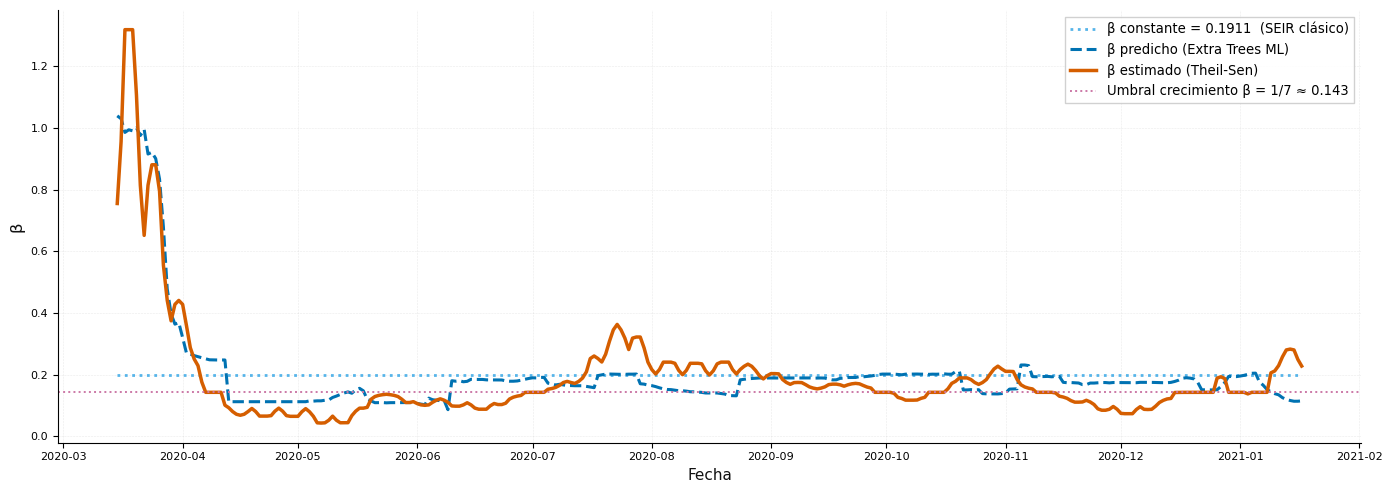

✅ Figura 12 guardada — figures/fig12_escenario1_beta_series.png


In [21]:
# ══════════════════════════════════════════════════════════════════════
# Celda 15 — FIGURA 12
# Escenario 1 — Series β comparadas (constante, predicho, estimado)
# Arranca desde 2020-03-15 (sin NaN)
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, beta_const,  color=C_CONST, linewidth=2,   linestyle=':',
        label=f'β constante = {beta_mean_fill:.4f}  (SEIR clásico)')
ax.plot(dates, beta_pred_s, color=C_PRED,  linewidth=2.2, linestyle='--',
        label='β predicho (Extra Trees ML)')
ax.plot(dates, beta_estim,  color=C_REAL,  linewidth=2.5,
        label='β estimado (Theil-Sen)')
ax.axhline(THRESHOLD, color=C_GOLD, linewidth=1.4, linestyle=':',
           label=f'Umbral crecimiento β = 1/7 ≈ {THRESHOLD:.3f}')

# # ax.set_title(f'Escenario 1 — series β · {TEST_COUNTRY}  ({s1_start_label} → {s1_end_label})',
#              fontsize=13, fontweight='bold', color=C_TEXT, pad=10)
ax.set_xlabel('Fecha', fontsize=11, color=C_TEXT)
ax.set_ylabel('β', fontsize=12, color=C_TEXT)
ax.legend(fontsize=9.5, framealpha=0.9)

# # Anotar primera oleada y segunda oleada si el rango las cubre
# date_arr = pd.to_datetime(dates)
# if pd.Timestamp('2020-03-14') in date_arr or date_arr.min() <= pd.Timestamp('2020-04-01'):
#     ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2020-05-15'),
#                alpha=0.05, color=C_REAL, label='1ª oleada (confinamiento)')
# if date_arr.max() >= pd.Timestamp('2020-09-01'):
#     ax.axvspan(pd.Timestamp('2020-09-01'), pd.Timestamp('2020-12-01'),
#                alpha=0.05, color=C_LOOSE, label='2ª oleada')

plt.tight_layout()
plt.savefig('figures_sci/fig12_escenario1_beta_series.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 12 guardada — figures/fig12_escenario1_beta_series.png')


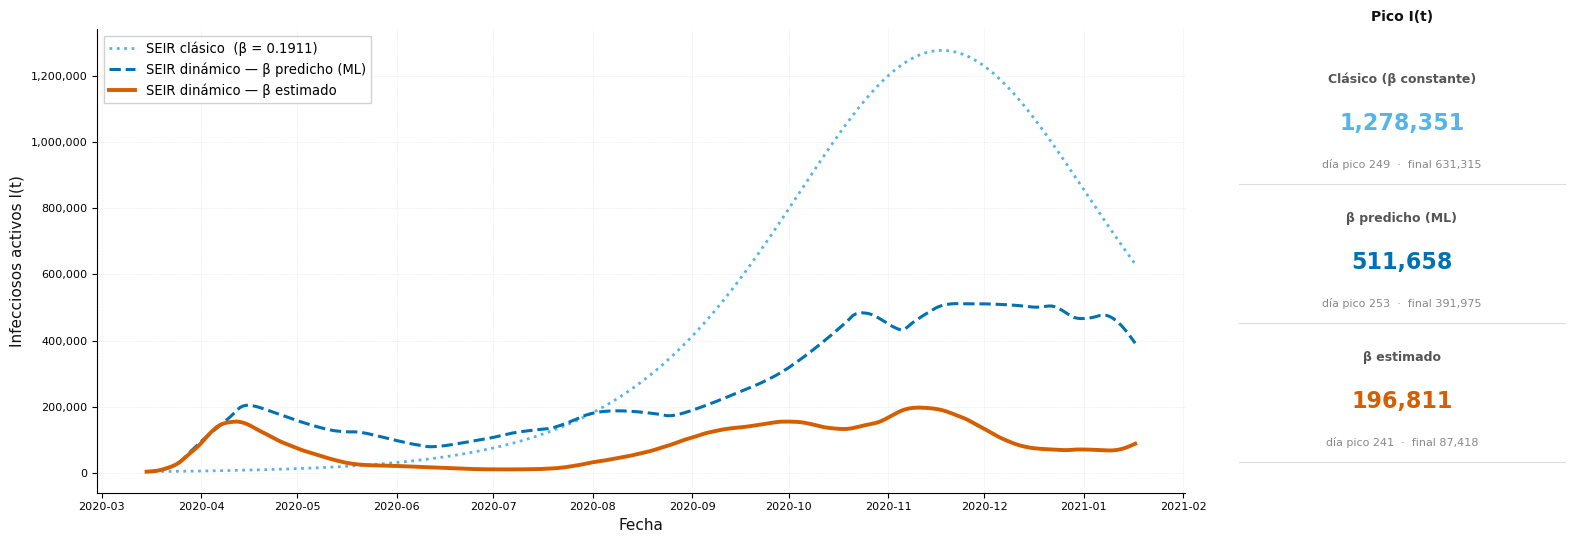

✅ Figura 13 guardada — figures/fig13_escenario1_seir_It.png


In [22]:
# ══════════════════════════════════════════════════════════════════════
# Celda 16 — FIGURA 13
# Escenario 1 — Trayectorias I(t): SEIR clásico vs dinámico
# ══════════════════════════════════════════════════════════════════════

fig, (ax_i, ax_sum) = plt.subplots(1, 2, figsize=(16, 5.5),
                                    gridspec_kw={'width_ratios': [3, 1]})

# ── Panel izquierdo: trayectorias I(t) ──
ax_i.plot(dates, traj_const['I'], color=C_CONST, linewidth=2,   linestyle=':',
          label=f'SEIR clásico  (β = {beta_mean_fill:.4f})')
ax_i.plot(dates, traj_pred['I'],  color=C_PRED,  linewidth=2.2, linestyle='--',
          label='SEIR dinámico — β predicho (ML)')
ax_i.plot(dates, traj_estim['I'], color=C_REAL,  linewidth=2.8,
          label='SEIR dinámico — β estimado')

# ax_i.set_title(f'Escenario 1 · I(t) — Infecciosos activos · {TEST_COUNTRY}\n'
#                f'{s1_start_label} → {s1_end_label}',
#                fontsize=12, fontweight='bold', color=C_TEXT, pad=10)
ax_i.set_xlabel('Fecha', fontsize=11, color=C_TEXT)
ax_i.set_ylabel('Infecciosos activos I(t)', fontsize=11, color=C_TEXT)
ax_i.legend(fontsize=9.5, framealpha=0.9)
ax_i.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Panel derecho: tarjetas de pico ──
ax_sum.set_facecolor('white'); ax_sum.axis('off')
ax_sum.set_xlim(0, 1); ax_sum.set_ylim(0, 3)
ax_sum.set_title('Pico I(t)', fontsize=10, fontweight='bold', color=C_TEXT)

scens = [
    ('Clásico (β constante)', traj_const, C_CONST),
    ('β predicho (ML)',       traj_pred,  C_PRED),
    ('β estimado',            traj_estim, C_REAL),
]
for i, (label, traj, col) in enumerate(scens):
    y0 = 2.65 - i * 0.90
    ax_sum.text(0.5, y0,        label,
                ha='center', fontsize=9,  color=C_MUTED,  fontweight='600')
    ax_sum.text(0.5, y0 - 0.30, f"{traj['I'].max():,.0f}",
                ha='center', fontsize=16, color=col,       fontweight='bold')
    ax_sum.text(0.5, y0 - 0.55,
                f"día pico {int(traj['I'].argmax())+1}  ·  final {int(traj['I'][-1]):,}",
                ha='center', fontsize=8, color='#888888')
    ax_sum.axhline(y0 - 0.65, xmin=0.05, xmax=0.95, color='#DDDDDD', linewidth=0.8)

plt.tight_layout()
plt.savefig('figures_sci/fig13_escenario1_seir_It.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 13 guardada — figures/fig13_escenario1_seir_It.png')


In [23]:
# ══════════════════════════════════════════════════════════════════════
# Celda 17 — Preparación Escenario 2
# Ventana de mínima varianza de β (min 60 días) y escenarios NPI
# ══════════════════════════════════════════════════════════════════════

# ── Selección automática de ventana de mínima varianza ──
W_MIN = 21
beta_s = test_df['beta'].values
min_var, best_start = np.inf, 0
for s in range(len(beta_s) - W_MIN):
    var = float(np.nanvar(beta_s[s:s+W_MIN]))
    if var < min_var:
        min_var    = var
        best_start = s

data_s2  = test_df.iloc[best_start : best_start + W_MIN].copy()
dates_s2 = data_s2['date'].values
I0_s2    = float(data_s2['I_real'].iloc[0]) if 'I_real' in data_s2.columns else 3000.0
E0_s2    = float(data_s2['E_real'].iloc[0]) if 'E_real' in data_s2.columns else 1500.0

print(f'Ventana Escenario 2: {data_s2["date"].iloc[0].date()} → {data_s2["date"].iloc[-1].date()}')
print(f'β medio en ventana: {data_s2["beta"].mean():.4f}')

# ── Definición de escenarios de política ──
# Valores reales de España en la ventana seleccionada
base_vals = {f: float(data_s2[f].median()) for f in FEATURES}

# Escenario restricciones altas
strict_vals = {
    'Facial_Coverings_lag14':           4.0,
    'Restrictions_on_gatherings_lag14': 4.0,
    'School_closing_lag14':             3.0,
    'mobility_transit_lag14':          -60.0,
    'Stay_at_home_lag14':               2.0,
}

# Escenario restricciones bajas
loose_vals = {
    'Facial_Coverings_lag14':           1.0,
    'Restrictions_on_gatherings_lag14': 1.0,
    'School_closing_lag14':             1.0,
    'mobility_transit_lag14':          -10.0,
    'Stay_at_home_lag14':               1.0,
}

# Predecir β para cada escenario (constante en toda la ventana)
beta_s2_base   = model.predict(data_s2[FEATURES])

df_strict = data_s2.copy()
df_loose  = data_s2.copy()
for f in FEATURES:
    df_strict[f] = strict_vals[f]
    df_loose[f]  = loose_vals[f]

beta_s2_strict = model.predict(df_strict[FEATURES])
beta_s2_loose  = model.predict(df_loose[FEATURES])

# Simulaciones SEIR
traj_s2_base   = simulate_seir(beta_s2_base,   population, E0_s2, I0_s2)
traj_s2_strict = simulate_seir(beta_s2_strict,  population, E0_s2, I0_s2)
traj_s2_loose  = simulate_seir(beta_s2_loose,   population, E0_s2, I0_s2)

print(f'\nPicos I(t) Escenario 2:')
print(f'  Base (ML):           {traj_s2_base["I"].max():,.0f}')
print(f'  Restricciones altas: {traj_s2_strict["I"].max():,.0f}')
print(f'  Restricciones bajas: {traj_s2_loose["I"].max():,.0f}')

Ventana Escenario 2: 2020-09-06 → 2020-09-26
β medio en ventana: 0.1661

Picos I(t) Escenario 2:
  Base (ML):           96,423
  Restricciones altas: 61,748
  Restricciones bajas: 206,160


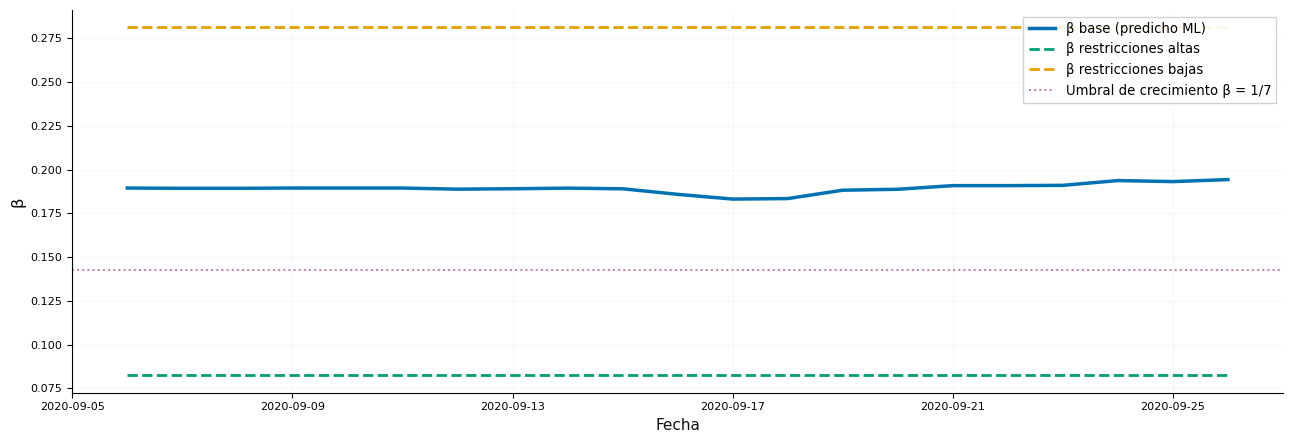

✅ Figura 14 guardada en figures/fig14_escenario2_beta_series.png


In [24]:
# ══════════════════════════════════════════════════════════════════════
# Celda 18 — FIGURA 14
# Escenario 2 — Series β: base, restricciones altas y bajas
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(dates_s2, beta_s2_base,   color=C_PRED,   linewidth=2.5,
        label='β base (predicho ML)')
ax.plot(dates_s2, beta_s2_strict, color=C_STRICT,  linewidth=2, linestyle='--',
        label='β restricciones altas')
ax.plot(dates_s2, beta_s2_loose,  color=C_LOOSE,   linewidth=2, linestyle='--',
        label='β restricciones bajas')
ax.axhline(THRESHOLD, color=C_GOLD, linewidth=1.4, linestyle=':',
           label=f'Umbral de crecimiento β = 1/7')

s2_start = pd.Timestamp(dates_s2[0]).date()
s2_end   = pd.Timestamp(dates_s2[-1]).date()
# ax.set_title(f'Escenario 2 — series β · {TEST_COUNTRY}  ({s2_start} → {s2_end})',
#              fontsize=12, fontweight='bold', color=C_TEXT, pad=10)
ax.set_xlabel('Fecha', fontsize=11, color=C_TEXT)
ax.set_ylabel('β', fontsize=12, color=C_TEXT)
ax.legend(fontsize=9.5, framealpha=0.9)

plt.tight_layout()
plt.savefig('figures_sci/fig14_escenario2_beta_series.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 14 guardada en figures/fig14_escenario2_beta_series.png')

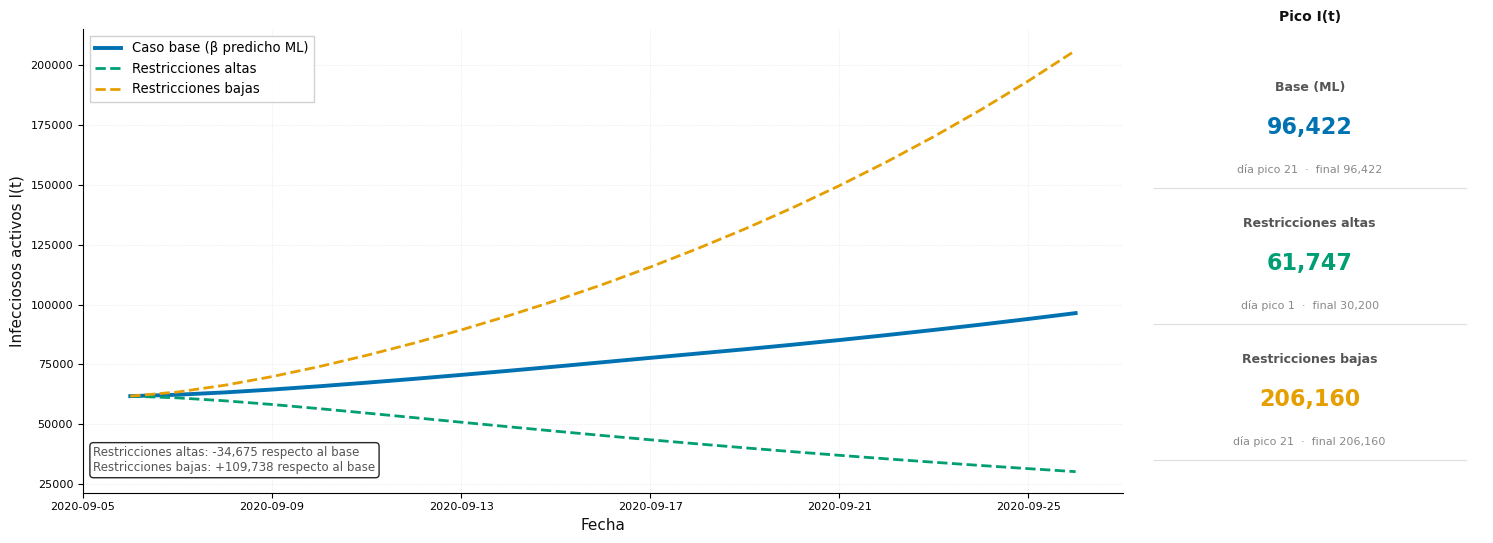

✅ Figura 15 guardada en figures/fig15_escenario2_seir_It.png

✅ TODAS LAS FIGURAS GENERADAS Y GUARDADAS EN figures/


FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'figures'

In [25]:
# ══════════════════════════════════════════════════════════════════════
# Celda 19 — FIGURA 15
# Escenario 2 — Trayectorias I(t) bajo los tres regímenes de política
# ══════════════════════════════════════════════════════════════════════

fig, (ax_main, ax_cards) = plt.subplots(1, 2, figsize=(15, 5.5),
                                         gridspec_kw={'width_ratios': [3, 1]})

# Panel izquierdo: trayectorias
ax_main.plot(dates_s2, traj_s2_base['I'],
             color=C_PRED, linewidth=2.8,
             label='Caso base (β predicho ML)')
ax_main.plot(dates_s2, traj_s2_strict['I'],
             color=C_STRICT, linewidth=2, linestyle='--',
             label='Restricciones altas')
ax_main.plot(dates_s2, traj_s2_loose['I'],
             color=C_LOOSE, linewidth=2, linestyle='--',
             label='Restricciones bajas')

# ax_main.set_title(f'Escenario 2 · I(t) — Infecciosos activos · {TEST_COUNTRY}\n'
#                   f'{s2_start} → {s2_end}',
#                   fontsize=12, fontweight='bold', color=C_TEXT, pad=10)
ax_main.set_xlabel('Fecha', fontsize=11, color=C_TEXT)
ax_main.set_ylabel('Infecciosos activos I(t)', fontsize=11, color=C_TEXT)
ax_main.legend(fontsize=9.5, framealpha=0.9)

# Panel derecho: tarjetas de resumen
ax_cards.set_facecolor('white'); ax_cards.axis('off')
ax_cards.set_xlim(0, 1); ax_cards.set_ylim(0, 3)
scens2 = [
    ('Base (ML)',             traj_s2_base,   C_PRED),
    ('Restricciones altas',   traj_s2_strict, C_STRICT),
    ('Restricciones bajas',   traj_s2_loose,  C_LOOSE),
]
for i, (label, traj, col) in enumerate(scens2):
    y0 = 2.6 - i * 0.88
    ax_cards.text(0.5, y0, label, ha='center', fontsize=9, color=C_MUTED, fontweight='600')
    ax_cards.text(0.5, y0 - 0.28, f'{int(traj["I"].max()):,}', ha='center',
                  fontsize=16, color=col, fontweight='bold')
    ax_cards.text(0.5, y0 - 0.53, f'día pico {int(traj["I"].argmax())+1}  ·  '
                  f'final {int(traj["I"][-1]):,}',
                  ha='center', fontsize=8, color='#888888')
    ax_cards.axhline(y0 - 0.63, xmin=0.05, xmax=0.95, color='#DDDDDD', linewidth=0.8)

ax_cards.set_title('Pico I(t)', fontsize=10, fontweight='bold', color=C_TEXT)

# Interpretación automática
peak_base   = int(traj_s2_base['I'].max())
peak_strict = int(traj_s2_strict['I'].max())
peak_loose  = int(traj_s2_loose['I'].max())
diff_s = peak_strict - peak_base
diff_l = peak_loose  - peak_base

interp = (f'Restricciones altas: {diff_s:+,} respecto al base\n'
          f'Restricciones bajas: {diff_l:+,} respecto al base')
ax_main.text(0.01, 0.04, interp, transform=ax_main.transAxes,
             fontsize=8.5, color=C_MUTED, va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig('figures_sci/fig15_escenario2_seir_It.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura 15 guardada en figures/fig15_escenario2_seir_It.png')

print('\n' + '='*60)
print('✅ TODAS LAS FIGURAS GENERADAS Y GUARDADAS EN figures/')
print('='*60)
import os
figs = sorted(os.listdir('figures'))
for f in figs:
    print(f'  • {f}')